# Interference Classification in O-RAN — MLP Baseline

A lightweight fully-connected baseline that classifies a flattened channel
**spectrogram** as **SOI**, **SOI+CWI** or **SOI+CI**. Architecture: Dense(128) →
Dense(128) → Dense(64) → Dense(3, softmax), all ReLU hidden units. It trades a little
accuracy for very low inference latency, which suits the near-RT RIC control loop.

**Data:** spectrogram PNGs under `directory`, one subfolder per class (`CI/`, `CWI/`,
`SOI/`), generated from a modified **srsRAN** LTE O-RAN testbed (not bundled — see the
project README).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.optimizers import Adam

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


Class names: ['CI', 'CWI', 'SOI']
Image shape: (256, 256, 3), Input size: 196608, Color mode: rgb


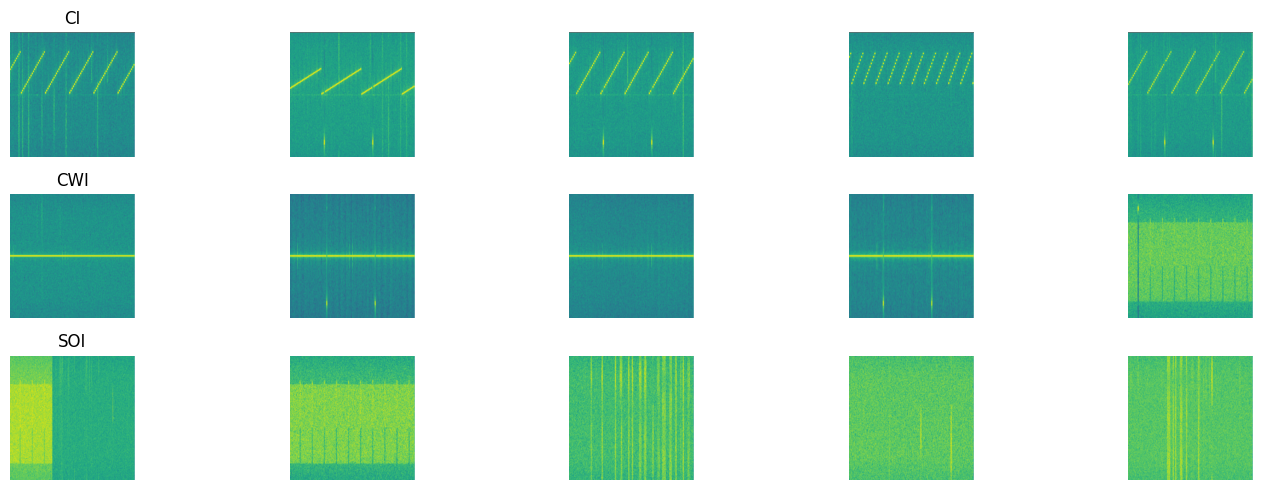

In [3]:
# Define dataset directory
directory = '/content/drive/MyDrive/cleaned'

# Only treat sub-directories as classes (ignores stray files like .DS_Store).
class_names = sorted(
    d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))
)
print("Class names:", class_names)

# Detect image resolution (assumes all images share the same size).
def get_image_shape(directory, class_name):
    class_dir = os.path.join(directory, class_name)
    image_path = os.path.join(class_dir, os.listdir(class_dir)[0])
    return np.array(Image.open(image_path)).shape

img_shape = get_image_shape(directory, class_names[0])
if len(img_shape) == 2:           # Grayscale
    height, width = img_shape
    channels = 1
    color_mode = 'grayscale'
else:                             # RGB
    height, width, channels = img_shape
    color_mode = 'rgb'
input_size = height * width * channels
print(f"Image shape: {img_shape}, Input size: {input_size}, Color mode: {color_mode}")

# Plot a few sample images per class.
def plot_sample_images(directory, class_names, num_samples=5):
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(15, 5))
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        selected = np.random.choice(os.listdir(class_dir), num_samples, replace=False)
        for j, file in enumerate(selected):
            img = Image.open(os.path.join(class_dir, file))
            axes[i, j].imshow(img, cmap='gray' if channels == 1 else None)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name)
    plt.tight_layout()
    plt.show()

plot_sample_images(directory, class_names)

In [4]:
# Leak-free, class-balanced 70/20/10 split.

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=directory,
    validation_split=0.3,
    subset='training',
    seed=123,
    image_size=(height, width),
    batch_size=32,
    color_mode=color_mode,
)
class_names = train_dataset.class_names

rest_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=directory,
    validation_split=0.3,
    subset='validation',
    seed=123,
    image_size=(height, width),
    batch_size=32,
    color_mode=color_mode,
)

# Split sizes are available instantly from .file_paths (no need to decode every image).
train_count = len(train_dataset.file_paths)
rest_count = len(rest_dataset.file_paths)
total = train_count + rest_count
print(f"Training images:        {train_count} ({train_count / total:.1%})")
print(f"Validation+Test images: {rest_count} ({rest_count / total:.1%})")


rest_dataset = rest_dataset.cache()
for _ in rest_dataset:
    pass
rest_batches = tf.data.experimental.cardinality(rest_dataset).numpy()
val_batches = int(round(rest_batches * (2.0 / 3.0)))
val_dataset = rest_dataset.take(val_batches)
test_dataset = rest_dataset.skip(val_batches)
print(f"  -> validation batches: {val_batches}, test batches: {rest_batches - val_batches}")

# Scale to [0,1] and flatten for the MLP input layer.
def flatten_image(image, label):
    image = image / 255.0
    return tf.reshape(image, [tf.shape(image)[0], -1]), label

train_dataset = train_dataset.map(flatten_image)
val_dataset = val_dataset.map(flatten_image)
test_dataset = test_dataset.map(flatten_image)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

Found 7912 files belonging to 3 classes.
Using 5539 files for training.
Found 7912 files belonging to 3 classes.
Using 2373 files for validation.
Training images:        5539 (70.0%)
Validation+Test images: 2373 (30.0%)
  -> validation batches: 50, test batches: 25


In [5]:
# # Define the MLP model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(input_size,)),
    tf.keras.layers.Dense(128, activation='relu'),  # First hidden layer
    tf.keras.layers.Dense(128, activation='relu'),  # Second hidden layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer for 3 classes
])

# model = tf.keras.Sequential([
#     tf.keras.layers.InputLayer(input_shape=(input_size,)),
#     tf.keras.layers.Dense(1024, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.2),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dense(3, activation='softmax')
# ])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,190,915 (96.10 MB)

 Trainable params: 25,190,915 (96.10 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# # Compile the model
# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

custom_lr = 0.0001  # Replace with your preferred value
optimizer = Adam(learning_rate=custom_lr)

# Compile the model with the custom optimizer
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,  # Adjust based on performance
    verbose=1  # Show progress bar
)

Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 829s 25ms/step - accuracy: 0.8363 - loss: 0.4501 - val_accuracy: 0.9169 - val_loss: 0.2260
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9067 - loss: 0.2456 - val_accuracy: 0.9513 - val_loss: 0.1366
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9583 - loss: 0.1399 - val_accuracy: 0.9837 - val_loss: 0.0909
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9578 - loss: 0.1383 - val_accuracy: 0.9488 - val_loss: 0.1175
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9715 - loss: 0.0961 - val_accuracy: 0.9162 - val_loss: 0.2344
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9711 - loss: 0.0990 - val_accuracy: 0.9700 - val_loss: 0.1237
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9763 - loss: 0.0822 - val_accuracy: 0.9794 - val_loss: 0.0899
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9648 - loss: 0.1104 - val_ac

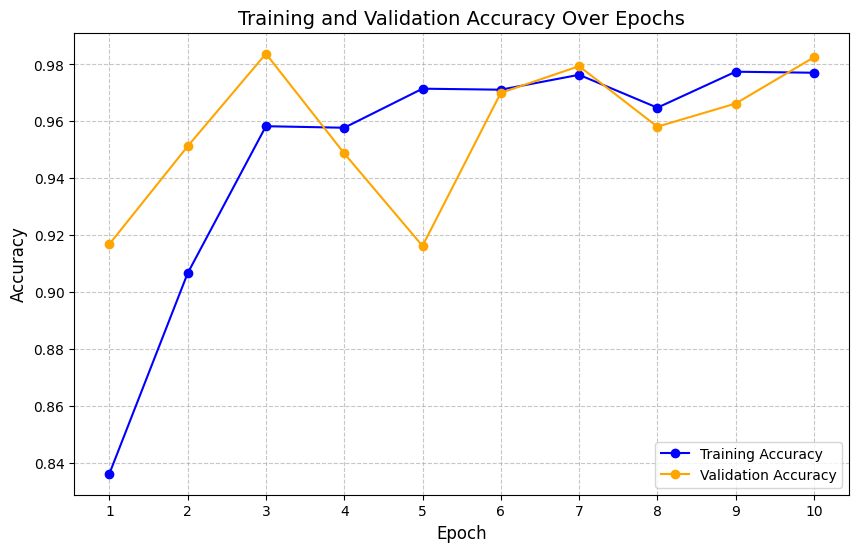

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')


plt.title('Training and Validation Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(len(history.history['accuracy'])), range(1, len(history.history['accuracy']) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test set class counts: {'CI': 192, 'CWI': 247, 'SOI': 334}
Test Accuracy: 0.9754
Test Precision: 0.9783
Test Recall: 0.9757
Test F1 Score: 0.9769


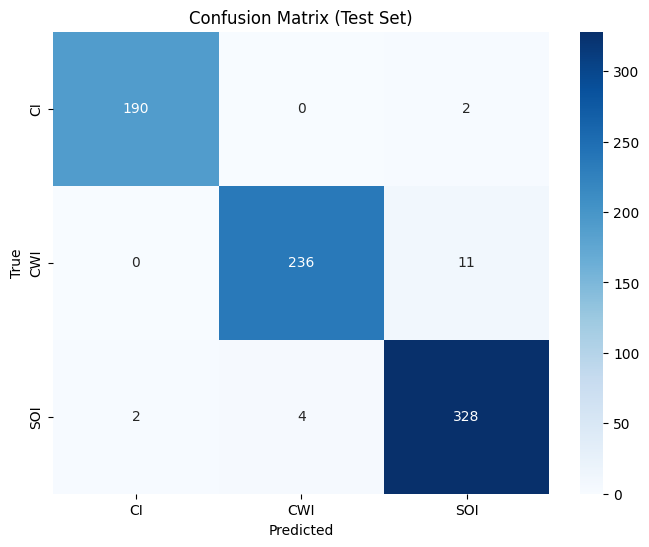

Average inference time per image: 0.379 ms

Classification Report (Test Set):
              precision    recall  f1-score   support

          CI       0.99      0.99      0.99       192
         CWI       0.98      0.96      0.97       247
         SOI       0.96      0.98      0.97       334

    accuracy                           0.98       773
   macro avg       0.98      0.98      0.98       773
weighted avg       0.98      0.98      0.98       773



In [8]:
# Predict on the test set. Warm up once (fills the cache + traces the graph) so the timed
# call below measures real inference latency, not first-call / data-loading overhead.
model.predict(test_dataset)
start_time = time.time()
predictions = model.predict(test_dataset)
end_time = time.time()

# True labels. test_dataset is cached, so this order matches `predictions`.
y_true = []
for _, label in test_dataset:
    y_true.extend(label.numpy())
y_true = np.array(y_true)
y_pred = np.argmax(predictions, axis=1)

# Sanity check: every class should be represented in the test set.
print("Test set class counts:",
      dict(zip(class_names, np.bincount(y_true, minlength=len(class_names)).tolist())))

# Evaluation metrics (macro-averaged across the 3 classes).
metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'F1 Score': f1_score(y_true, y_pred, average='macro', zero_division=0),
}
for metric_name, value in metrics.items():
    print(f"Test {metric_name}: {value:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Average inference time per image (measured on the warm run above).
num_test_images = len(y_true)
print(f"Average inference time per image: {(end_time - start_time) / num_test_images * 1000:.3f} ms")

# Per-class report
print("\nClassification Report (Test Set):")
print(classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                            target_names=class_names, zero_division=0))

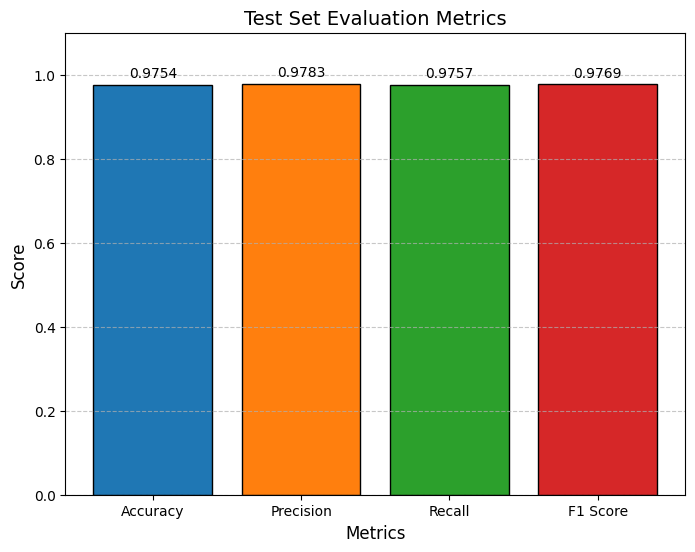

In [9]:
# Plot the evaluation metrics as a bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

# Customize the plot
plt.ylim(0, 1.1)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Test Set Evaluation Metrics', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

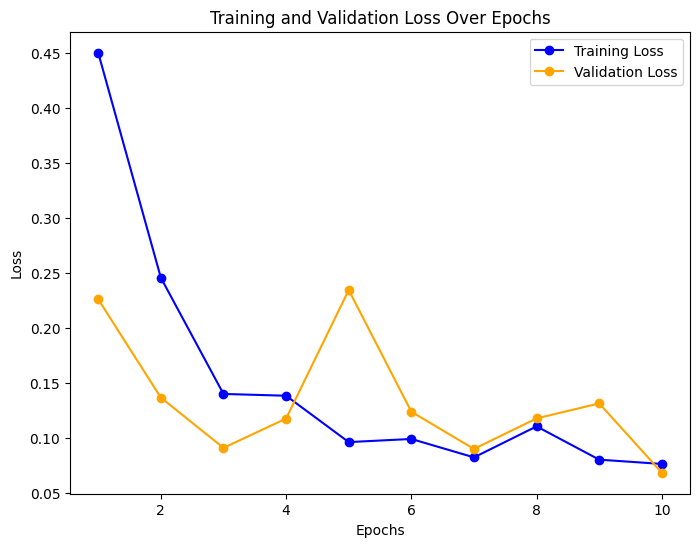

In [10]:
# Training and validation loss from the live training history.
plt.figure(figsize=(8, 6))
epochs = range(1, len(history.history['loss']) + 1)
plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()